Epoch 20/150, Train Loss: 0.0360, Val Loss: 0.0408
Epoch 40/150, Train Loss: 0.0191, Val Loss: 0.0220
Epoch 60/150, Train Loss: 0.0049, Val Loss: 0.0052
Epoch 80/150, Train Loss: 0.0015, Val Loss: 0.0014
Epoch 100/150, Train Loss: 0.0012, Val Loss: 0.0012
Epoch 120/150, Train Loss: 0.0011, Val Loss: 0.0012
Epoch 140/150, Train Loss: 0.0011, Val Loss: 0.0012
Test MSE: 0.001243435894139111
Test MAE: 0.02788112312555313
Naive baseline MSE: 0.311259925365448


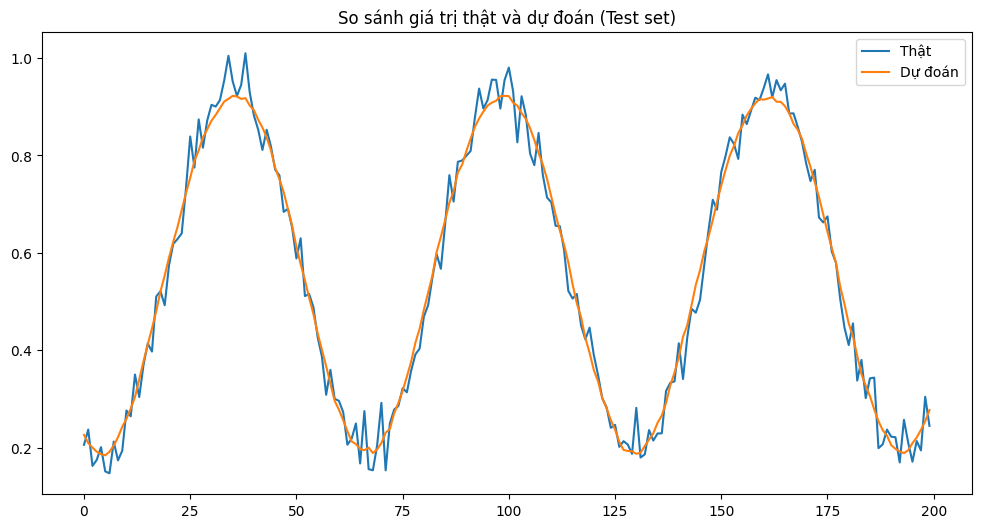

Seq_length=10, Test MSE=0.0267
Seq_length=20, Test MSE=0.0177
Seq_length=30, Test MSE=0.0077
Hidden_size=16, Test MSE=0.0297
Hidden_size=32, Test MSE=0.0383
Hidden_size=64, Test MSE=0.0058


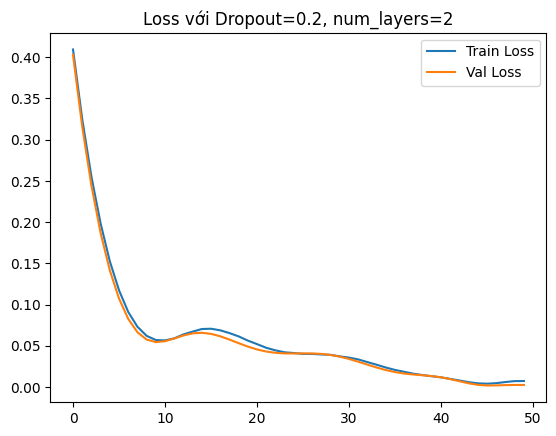

In [1]:
#bài 1
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# Sinh dữ liệu giả định
# -----------------------------
np.random.seed(42)
t = np.arange(0, 1000, 0.1)
feature_1 = np.sin(t)
feature_2 = np.cos(t)
feature_3 = 0.001*t + np.random.normal(0,0.05,len(t))
target = 0.5*feature_1 + 0.3*feature_2 + 0.2*feature_3 + np.random.normal(0,0.05,len(t))

data = np.vstack([feature_1, feature_2, feature_3, target]).T

# -----------------------------
# A. Tiền xử lý
# -----------------------------
train_size = int(0.7*len(data))
val_size = int(0.15*len(data))
test_size = len(data) - train_size - val_size

train_data = data[:train_size]
val_data = data[train_size:train_size+val_size]
test_data = data[train_size+val_size:]

scaler = MinMaxScaler()
scaler.fit(train_data)
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

def create_sequences(dataset, seq_length):
    X, y = [], []
    for i in range(len(dataset)-seq_length):
        X.append(dataset[i:i+seq_length, :-1])
        y.append(dataset[i+seq_length, -1])
    return np.array(X), np.array(y)

seq_length = 20
X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val = create_sequences(val_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# -----------------------------
# B. Mô hình RNN
# -----------------------------
class RNNModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = RNNModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Huấn luyện
# -----------------------------
train_losses, val_losses = [], []
epochs = 150

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# -----------------------------
# C. Đánh giá
# -----------------------------
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()
    y_true = y_test.numpy()

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
print("Test MSE:", mse)
print("Test MAE:", mae)

# Baseline naive
y_naive = X_test[:, -1, -1].numpy().reshape(-1,1)
mse_naive = mean_squared_error(y_true, y_naive)
print("Naive baseline MSE:", mse_naive)

# -----------------------------
# Vẽ biểu đồ
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_true[:200], label="Thật")
plt.plot(y_pred[:200], label="Dự đoán")
plt.legend()
plt.title("So sánh giá trị thật và dự đoán (Test set)")
plt.show()

# -----------------------------
# D. Phân tích nâng cao
# -----------------------------
def experiment(seq_length, hidden_size):
    X_train, y_train = create_sequences(train_scaled, seq_length)
    X_val, y_val = create_sequences(val_scaled, seq_length)
    X_test, y_test = create_sequences(test_scaled, seq_length)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

    model = RNNModel(input_size=3, hidden_size=hidden_size, output_size=1)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(50):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).numpy()
        mse = mean_squared_error(y_test.numpy(), y_pred)
    return mse

for seq in [10,20,30]:
    print(f"Seq_length={seq}, Test MSE={experiment(seq,32):.4f}")

for hs in [16,32,64]:
    print(f"Hidden_size={hs}, Test MSE={experiment(20,hs):.4f}")

# Dropout thử nghiệm
class RNNDropout(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, dropout=0.2, num_layers=2)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = RNNDropout()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_output = model(X_val)
        val_loss = criterion(val_output, y_val)
        val_losses.append(val_loss.item())

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss với Dropout=0.2, num_layers=2")
plt.show()


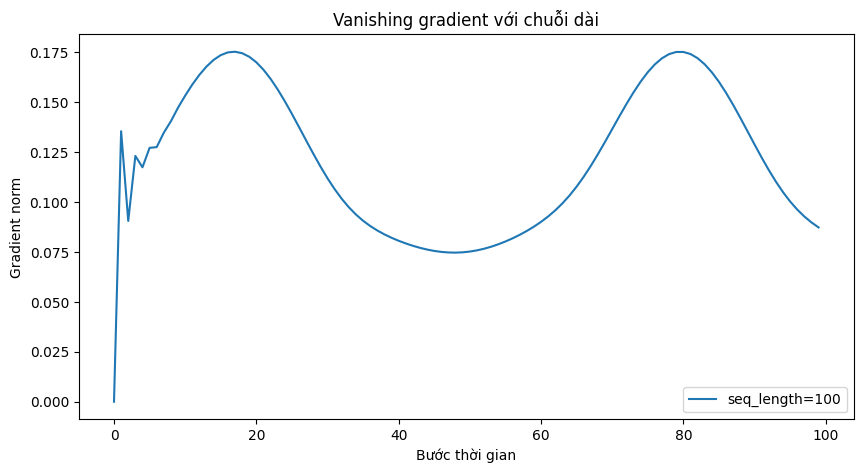

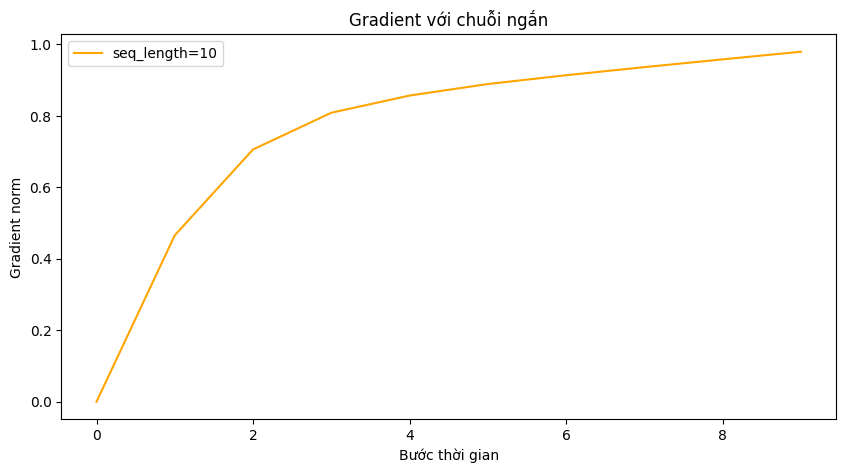

In [2]:
#bài 2: quan sát hiện tượng vanishing garden
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Sinh dữ liệu sin
# -----------------------------
np.random.seed(42)
t = np.linspace(0, 50, 500)
data = np.sin(t)

# -----------------------------
# Hàm tạo chuỗi
# -----------------------------
def create_sequences(dataset, seq_length):
    X, y = [], []
    for i in range(len(dataset)-seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length])
    return np.array(X), np.array(y)

# -----------------------------
# Mô hình RNN nhỏ
# -----------------------------
class SmallRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# -----------------------------
# Hàm đo gradient theo từng bước
# -----------------------------
def measure_gradients(seq_length):
    X, y = create_sequences(data, seq_length)
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (samples, seq_length, 1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    model = SmallRNN()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # Chỉ lấy một batch nhỏ để quan sát
    x_batch = X[:1]
    y_batch = y[:1]

    # Forward
    outputs, hidden = model.rnn(x_batch)
    final_out = model.fc(outputs[:, -1, :])
    loss = criterion(final_out, y_batch)

    # Lưu gradient norm cho từng bước
    grad_norms = []
    for t in range(seq_length):
        optimizer.zero_grad()
        out_t = model.fc(outputs[:, t, :])
        loss_t = criterion(out_t, y_batch)
        loss_t.backward(retain_graph=True)
        grad_norm = model.rnn.weight_hh_l0.grad.norm().item()
        grad_norms.append(grad_norm)

    return grad_norms

# -----------------------------
# Thử với seq_length=100
# -----------------------------
grad_norms_100 = measure_gradients(100)
plt.figure(figsize=(10,5))
plt.plot(grad_norms_100, label="seq_length=100")
plt.xlabel("Bước thời gian")
plt.ylabel("Gradient norm")
plt.title("Vanishing gradient với chuỗi dài")
plt.legend()
plt.show()

# -----------------------------
# Thử với seq_length=10
# -----------------------------
grad_norms_10 = measure_gradients(10)
plt.figure(figsize=(10,5))
plt.plot(grad_norms_10, label="seq_length=10", color="orange")
plt.xlabel("Bước thời gian")
plt.ylabel("Gradient norm")
plt.title("Gradient với chuỗi ngắn")
plt.legend()
plt.show()


In [3]:
#bài 3: so sánh RNN vs baseline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# Sinh dữ liệu sin
# -----------------------------
np.random.seed(42)
t = np.linspace(0, 100, 1000)
data = np.sin(t)

def create_sequences(dataset, seq_length):
    X, y = [], []
    for i in range(len(dataset)-seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

# -----------------------------
# RNN Model
# -----------------------------
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch, seq_length, 1)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# -----------------------------
# ANN Model (MLP)
# -----------------------------
class ANNModel(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# -----------------------------
# Training function
# -----------------------------
def train_model(model, X, y, epochs=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_pred = model(X).numpy()
    return mean_squared_error(y.numpy(), y_pred)

# -----------------------------
# So sánh 3 mô hình
# -----------------------------
mse_rnn = train_model(RNNModel(), X, y)
mse_ann = train_model(ANNModel(), X, y)

# Baseline naive: y_pred = x[-1]
y_naive = X[:, -1].numpy().reshape(-1,1)
mse_naive = mean_squared_error(y.numpy(), y_naive)

print("MSE RNN:", mse_rnn)
print("MSE ANN:", mse_ann)
print("MSE Naive:", mse_naive)


MSE RNN: 0.00044587469892576337
MSE ANN: 0.00013831914111506194
MSE Naive: 0.004959112498909235
